In [4]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
import string

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import xgboost as xgb
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amits\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\amits\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
# Load Dataset

df = pd.read_csv('Tweets.csv')
print("Dataset Shape:", df.shape)
print(df['sentiment'].value_counts())

Dataset Shape: (27481, 4)
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


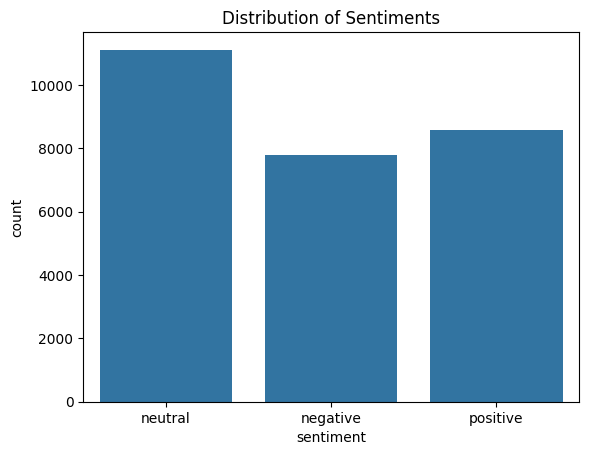

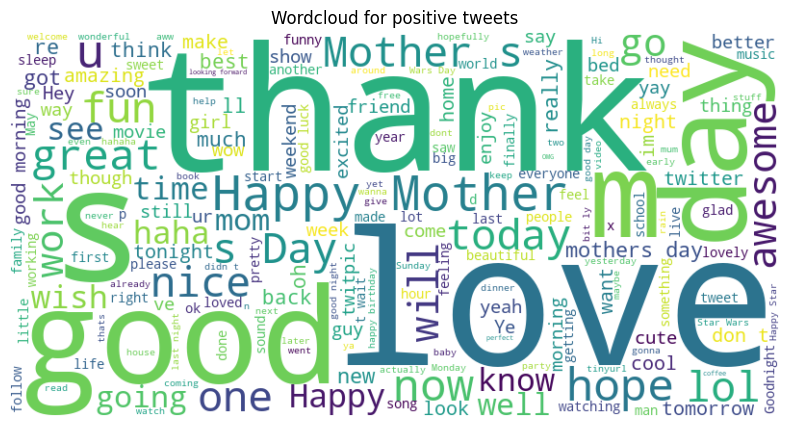

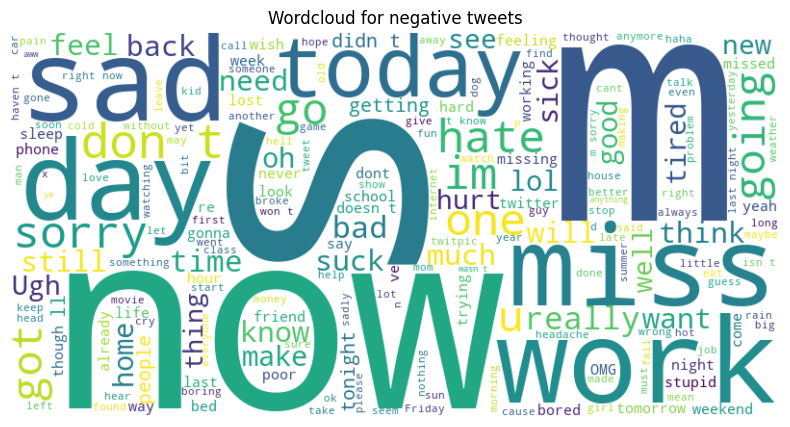

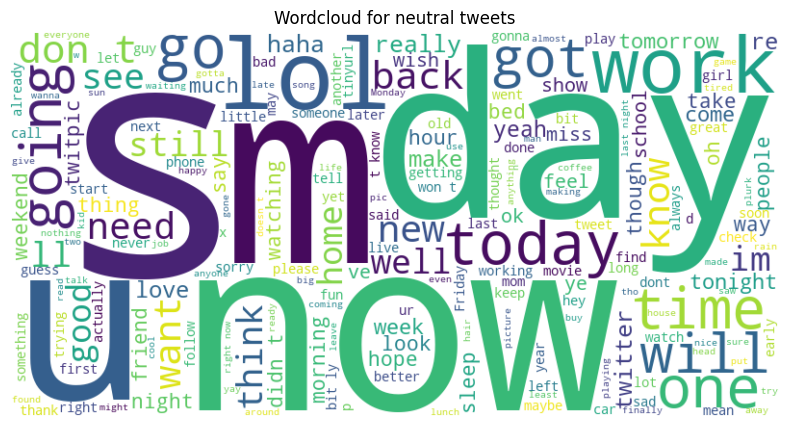

In [6]:
# EDA (Optional Visuals)
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiments")
plt.show()

for sentiment in ['positive', 'negative', 'neutral']:
    text = ' '.join(df[df['sentiment']==sentiment]['text'].astype(str).dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Wordcloud for {sentiment} tweets")
    plt.show()

In [7]:
# Text Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)       
    text = re.sub(r'\@\w+|\#', '', text)                     
    text = re.sub(r'[^a-z\s]', '', text)                     
    text = re.sub(r'\s+', ' ', text).strip()                
    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return ' '.join(tokens)
df['clean_text'] = df['text'].apply(clean_text)

In [8]:
# Train-Test Split
X = df['clean_text']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# Feature Extraction (TF-IDF)
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [10]:
# Ensemble Model: RandomForest + XGBoost + LogisticRegression
rf_clf = RandomForestClassifier(n_estimators=500, max_depth=50, random_state=42, class_weight='balanced')
xgb_clf = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
lr_clf = LogisticRegression(max_iter=500, class_weight='balanced')
ensemble = VotingClassifier(
    estimators=[('rf', rf_clf), ('xgb', xgb_clf), ('lr', lr_clf)],
    voting='soft' 
)
ensemble.fit(X_train_tfidf, y_train)

C:\Users\amits\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [00:31:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",50
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


Ensemble Accuracy: 0.712934327815172

Classification Report:
               precision    recall  f1-score   support

    negative       0.76      0.63      0.69      1556
     neutral       0.65      0.77      0.70      2224
    positive       0.78      0.71      0.75      1717

    accuracy                           0.71      5497
   macro avg       0.73      0.71      0.71      5497
weighted avg       0.72      0.71      0.71      5497



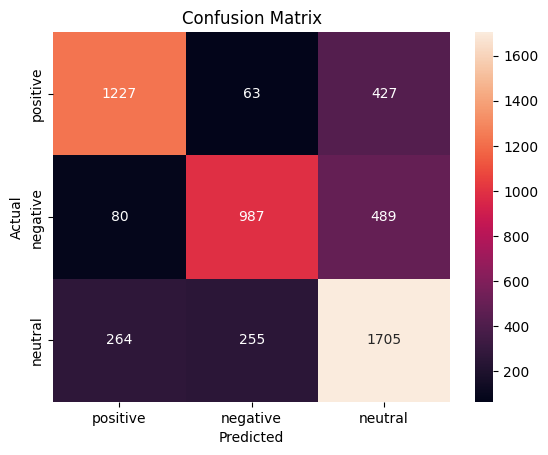

In [11]:
# Evaluation
y_pred = ensemble.predict(X_test_tfidf)
print("Ensemble Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=['positive','negative','neutral'])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['positive','negative','neutral'], yticklabels=['positive','negative','neutral'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

In [13]:
# Predict New Tweet
def predict_sentiment(text):
    clean = clean_text(text)
    vector = tfidf.transform([clean])
    return ensemble.predict(vector)[0]
new_tweet = "I am so happy with my results!"
print("Tweet:", new_tweet)
print("Predicted sentiment:", predict_sentiment(new_tweet))

Tweet: I am so happy with my results!
Predicted sentiment: positive


In [14]:
import pickle

# Save the ensemble model
with open("ensemble_model.pkl", "wb") as f:
    pickle.dump(ensemble, f)

# Save the TF-IDF vectorizer

In [1]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
df = pd.read_csv('Tweets.csv')

# Text preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment']
)

# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Ensemble model
rf_clf = RandomForestClassifier(n_estimators=500, max_depth=50, random_state=42, class_weight='balanced')
xgb_clf = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
lr_clf = LogisticRegression(max_iter=500, class_weight='balanced')

ensemble = VotingClassifier(
    estimators=[('rf', rf_clf), ('xgb', xgb_clf), ('lr', lr_clf)],
    voting='soft'
)

# Train model
ensemble.fit(X_train_tfidf, y_train)

# Save model and vectorizer
with open("ensemble_model.pkl", "wb") as f:
    pickle.dump(ensemble, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amits\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\amits\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
C:\Users\amits\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [00:42:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model and vectorizer saved successfully!
